# Simple Linear Regression – Part-1

## Objective
To understand and implement Simple Linear Regression using Python and Machine Learning.

### Mathematical Model
$$ y = mx + c $$

- **x**: Independent variable
- **y**: Dependent variable
- **m**: Slope
- **c**: Intercept


In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Step 1: Create Dataset
We create a small dataset representing study hours and exam scores.

In [2]:
# Create a simple dataset containing study hours and corresponding scores
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8],   # Independent variable: number of hours studied
    "Score": [35, 40, 50, 55, 65, 70, 75, 85]  # Dependent variable: score obtained
}

In [6]:
# Convert the dictionary into a Pandas DataFrame for easy analysis and modeling
df = pd.DataFrame(data)

In [5]:
# Display the dataset- first 5 rows
df.head()

,Hours,Score
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65


## Step 2: Define Independent and Dependent Variables

In [7]:
# Independent and dependent variables
X = df[["Hours"]]
y = df["Score"]

## Step 3: Visualize the Dataset


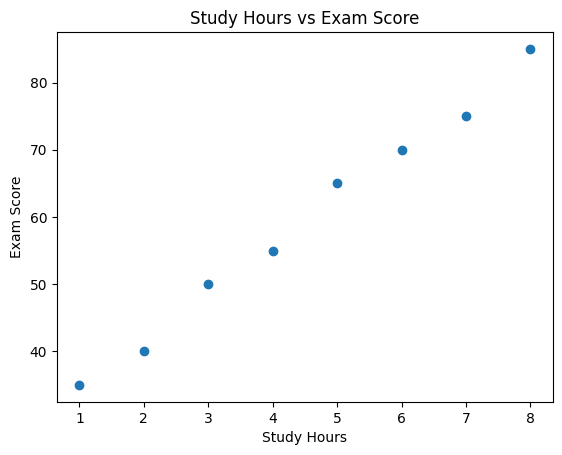

In [8]:
plt.scatter(df['Hours'], df['Score'])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.show()

## Step 4: Train the Linear Regression Model

In [9]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Simple Linear Regression on CSV Dataset
**Objective**

To implement Simple Linear Regression to predict Placement Package (LPA) based on CGPA.



```
# This is formatted as code
```

**Part 1: Train and Save the Model**

## Step 1: Import Required Libraries

In [ ]:
# Import pandas for data handling
import pandas as pd

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Linear Regression model
from sklearn.linear_model import LinearRegression


## Step 2: Load Dataset from CSV File

In [ ]:
# Read the dataset from CSV file
df = pd.read_csv('/content/drive/MyDrive/Dataset/Placement.csv')

## Step 3: Understand the Dataset

In [10]:
# Display the shape of the dataset (rows, columns)
df.shape

(8, 2)

In [11]:
# Display dataset information such as column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   8 non-null      int64
 1   Score   8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes


In [12]:
# Display statistical summary of the dataset
df.describe()

,Hours,Score
count,8.00000,8.000000
mean,4.50000,59.375000
std,2.44949,17.410485
min,1.00000,35.000000
25%,2.75000,47.500000
50%,4.50000,60.000000
75%,6.25000,71.250000
max,8.00000,85.000000


In [ ]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


## Step 5: Define Independent and Dependent Variables

In [ ]:
# Independent variable (input feature)
X = df[['cgpa']]

# Dependent variable (target)
y = df['package']

## Step 6: Split Data into Training and Testing Sets

In [ ]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)


## Step 7: Create and Train Linear Regression Model

In [ ]:
# Create Linear Regression model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)


LinearRegression()

**Prediction Using User Input**

In [ ]:
# Take CGPA value from the user
cgpa = float(input("Enter CGPA: "))

# Convert input into 2D array format required by the model
cgpa_input = [[cgpa]]

# Predict the placement package using the trained model
predicted_package = model.predict(cgpa_input)

# Display the prediction
print("Entered CGPA:", cgpa)
print("Predicted Package (in LPA):", predicted_package[0])


Enter CGPA: 5
Entered CGPA: 5.0
Predicted Package (in LPA): 1.8936479448824457


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Save the Model

In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('SLRModel.pkl','wb'))

**Part 2: Create Flask Backend**

In [ ]:
from flask import Flask,render_template,request
import pickle
import numpy as np

app=Flask(__name__)

model=pickle.load(open("SLRModel.pkl","rb"))

@app.route('/')
def home():
    return render_template("index.html")

@app.route('/predict',methods=['POST'])

def predict():

    cgpa=float(request.form['cgpa'])

    prediction=model.predict(np.array([[cgpa]]))

    return render_template(
        "index.html",
        prediction_text=f"Predicted Package : {prediction[0]:.2f} LPA"
    )

if __name__=="__main__":
    app.run(debug=True)

**Part 3: Create the HTML Frontend**

In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Student Package Predictor</title>

    <style>

        *{
            margin:0;
            padding:0;
            box-sizing:border-box;
            font-family:Arial, Helvetica, sans-serif;
        }

        body{
            background:#f4f7fc;
            display:flex;
            justify-content:center;
            align-items:center;
            height:100vh;
        }

        .container{

            width:420px;
            background:white;
            padding:35px;
            border-radius:15px;
            box-shadow:0px 8px 20px rgba(0,0,0,0.2);
            text-align:center;

        }

        h1{

            color:#0d47a1;
            margin-bottom:10px;

        }

        h3{

            color:#555;
            margin-bottom:25px;

        }

        label{

            display:block;
            text-align:left;
            font-weight:bold;
            margin-bottom:8px;

        }

        input{

            width:100%;
            padding:12px;
            font-size:16px;
            border:1px solid #ccc;
            border-radius:8px;
            margin-bottom:20px;

        }

        button{

            width:100%;
            padding:12px;
            background:#1565c0;
            color:white;
            border:none;
            border-radius:8px;
            font-size:18px;
            cursor:pointer;
            transition:0.3s;

        }

        button:hover{

            background:#0d47a1;

        }

        .result{

            margin-top:25px;
            padding:15px;
            border-radius:8px;
            background:#e8f5e9;
            color:green;
            font-size:20px;
            font-weight:bold;

        }

        footer{

            margin-top:20px;
            font-size:13px;
            color:#777;

        }

    </style>

</head>

<body>

<div class="container">

    <h1>Student Package Predictor</h1>

    <h3>Simple Linear Regression</h3>

    <form action="/predict" method="POST">

        <label>Enter Student CGPA</label>

        <input
        type="number"
        name="cgpa"
        step="0.01"
        min="0"
        max="10"
        placeholder="Example : 8.45"
        required>

        <button type="submit">
            Predict Package
        </button>

    </form>

    {% if prediction_text %}
    <div class="result">
        {{ prediction_text }}
    </div>
    {% endif %}

    <footer>

        Machine Learning by Mr. Aditya Tanaji Gawade

    </footer>

</div>

</body>
</html>